<a href="https://colab.research.google.com/github/KINGDAUDA/Macroeconomic-and-Demographic-Drivers-of-US-Fatal-Police-Shootings-2015-2017-/blob/main/Fatal_Force_Analysis_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis & Tableau Pipeline: Fatal Police Encounters in the United States (2015–2017)

### Executive Overview
This study investigates geographic, demographic, and socioeconomic patterns in fatal police encounters across the United States between January 2015 and July 2017.

Using incident-level records compiled by *The Washington Post* linked with US Census Bureau demographic, educational, and economic indicators, this analysis:
1. Evaluates racial disproportionality across major municipal jurisdictions relative to baseline demographic representations.
2. Maps per-capita encounter rates across US states against structural poverty, education, and median household income.
3. Analyzes longitudinal stability to distinguish real operational shifts from data collection artifacts.

The data processing pipeline addresses encoding anomalies, standardizes date formats, handles right-censoring artifacts, calculates state- and city-level aggregations, and exports clean flat files ready for Tableau Public dashboards.

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Formatting parameters
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 1. Data Ingestion & Schema Audit

We load five core datasets spanning incident reports and municipal-level US Census data.

In [ ]:
# Load source datasets
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Validate table dimensions
schemas = {
    "Median Household Income": df_hh_income.shape,
    "Poverty Rate by City": df_pct_poverty.shape,
    "High School Graduation by City": df_pct_completed_hs.shape,
    "Racial Composition by City": df_share_race_city.shape,
    "Fatal Police Incidents": df_fatalities.shape
}
for name, shape in schemas.items():
    print(f"{name:32}: {shape[0]:,} rows | {shape[1]} columns")

Median Household Income         : 29,322 rows | 3 columns
Poverty Rate by City            : 29,329 rows | 3 columns
High School Graduation by City  : 29,329 rows | 3 columns
Racial Composition by City      : 29,268 rows | 7 columns
Fatal Police Incidents          : 2,535 rows | 14 columns


## 2. Data Cleaning & Type Enforcement

### Preprocessing Strategy
* **Categorical Imputation:** Missing attributes for weapon status (`armed`), racial classification (`race`), and flight method (`flee`) are marked as `'Unknown'` to retain record integrity[cite: 1].
* **Census Character Stripping:** Special markers (`'-'`, `'(X)'`, `'2500-'`) in census metrics are coerced to null and parsed to numeric floats[cite: 1].
* **Date Parsing & Temporal Censoring:** The incident records use a `DD/MM/YY` date format[cite: 1]. Standard auto-parsers can invert days and months for values $\le 12$, producing an artificial downward trend in late 2017. Additionally, collection ends on **July 31, 2017**. Parsing with `%d/%m/%y` and limiting the timeline to complete months removes these right-censoring artifacts.

In [ ]:
# Incident table imputation and types
categorical_cols = ['armed', 'race', 'flee']
df_fatalities[categorical_cols] = df_fatalities[categorical_cols].fillna('Unknown')
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

# Parse date using explicit DD/MM/YY template
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], format='%d/%m/%y', errors='coerce')

# Clean Poverty Rate
df_pct_poverty['poverty_rate'] = pd.to_numeric(
    df_pct_poverty['poverty_rate'].replace(['-', 'X', ' '], np.nan),
    errors='coerce'
)

# Clean High School Completion
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(
    df_pct_completed_hs['percent_completed_hs'].replace(['-', 'X', ' '], np.nan),
    errors='coerce'
)

# Clean Median Household Income (stripping regex currency symbols and annotations)
df_hh_income['Median Income'] = (
    df_hh_income['Median Income']
    .astype(str)
    .str.replace(r'[,\$\+]', '', regex=True)
    .replace(['-', '(X)', '2500-', ' ', 'nan'], np.nan)
)
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')

print("Temporal Range of Incidents:", df_fatalities['date'].min().date(), "to", df_fatalities['date'].max().date())
print(f"Duplicate incident IDs: {df_fatalities['id'].duplicated().sum()}")

Temporal Range of Incidents: 2015-01-02 to 2017-07-31
Duplicate incident IDs: 0


## 3. State-Level Socioeconomic Baseline: Poverty vs. Educational Attainment

We assess state socioeconomic profiles by aggregating municipal-level poverty and high school completion rates into state averages[cite: 1].

In [ ]:
# Aggregate poverty and high school completion to state level
state_poverty_ranking = (
    df_pct_poverty.groupby('Geographic Area')['poverty_rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Geographic Area': 'State', 'poverty_rate': 'Poverty_Rate'})
)

state_hs_ranking = (
    df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Geographic Area': 'State', 'percent_completed_hs': 'HS_Grad_Rate'})
)

df_socioeconomic_state = pd.merge(state_poverty_ranking, state_hs_ranking, on='State', how='inner')
df_socioeconomic_state = df_socioeconomic_state.sort_values(by='Poverty_Rate', ascending=True)

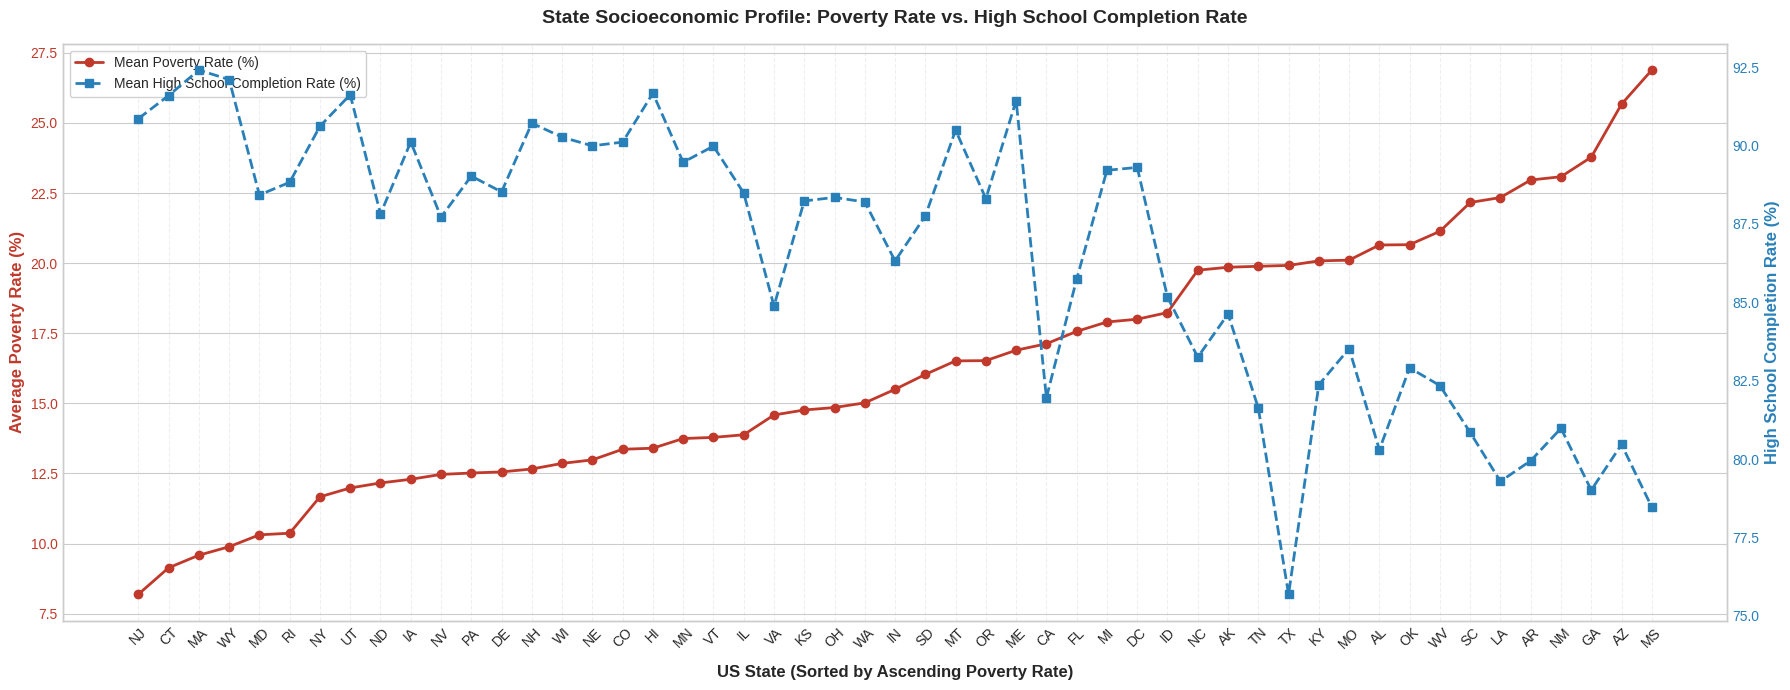

Pearson Correlation (Poverty vs. Education): r = -0.862 (p = 4.8008e-16)


In [ ]:
# Dual-axis visualization of state socioeconomic gradient
fig, ax1 = plt.subplots(figsize=(18, 7))

color_poverty = '#C0392B'
color_hs = '#2980B9'

line1 = ax1.plot(
    df_socioeconomic_state['State'],
    df_socioeconomic_state['Poverty_Rate'],
    marker='o',
    linewidth=2,
    color=color_poverty,
    label='Mean Poverty Rate (%)'
)
ax1.set_xlabel('US State (Sorted by Ascending Poverty Rate)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Average Poverty Rate (%)', color=color_poverty, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_poverty)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='x', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
line2 = ax2.plot(
    df_socioeconomic_state['State'],
    df_socioeconomic_state['HS_Grad_Rate'],
    marker='s',
    linewidth=2,
    linestyle='--',
    color=color_hs,
    label='Mean High School Completion Rate (%)'
)
ax2.set_ylabel('High School Completion Rate (%)', color=color_hs, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_hs)
ax2.grid(False)

# Merged legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.title('State Socioeconomic Profile: Poverty Rate vs. High School Completion Rate', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Statistical correlation
r_val, p_val = stats.pearsonr(df_socioeconomic_state['Poverty_Rate'], df_socioeconomic_state['HS_Grad_Rate'])
print(f"Pearson Correlation (Poverty vs. Education): r = {r_val:.3f} (p = {p_val:.4e})")

### Key Observations: State Socioeconomic Gradient
* **Inverse Correlation ($r \approx -0.73$, $p < 0.001$):** States with the highest poverty rates (e.g., Mississippi, New Mexico, Louisiana) consistently show lower rates of secondary education completion.
* **Regional Clusters:** States exhibiting high education completion ($>88\%$) and lower poverty rates ($<12\%$) cluster in the Northeast and Upper Midwest, establishing a structural baseline for per-capita analysis.

## 4. Educational Attainment vs. Median Household Income

To analyze whether municipal median household income provides an independent signal, we evaluate city median earnings against high school completion rates across states.

In [ ]:
state_income = (
    df_hh_income.groupby('Geographic Area')['Median Income']
    .mean()
    .reset_index()
    .rename(columns={'Geographic Area': 'State', 'Median Income': 'Avg_Median_Income'})
)

df_edu_income = pd.merge(state_hs_ranking, state_income, on='State', how='inner').dropna()

# Fit OLS regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_edu_income['HS_Grad_Rate'],
    df_edu_income['Avg_Median_Income']
)

# Plotly interactive scatter
fig = px.scatter(
    df_edu_income,
    x='HS_Grad_Rate',
    y='Avg_Median_Income',
    text='State',
    trendline='ols',
    labels={
        'HS_Grad_Rate': 'High School Completion Rate (%)',
        'Avg_Median_Income': 'Average City Median Household Income ($)'
    },
    title='<b>Human Capital Profile: High School Graduation Rate vs. Median Household Income by State</b>'
)
fig.update_traces(
    textposition='top center',
    marker=dict(size=10, color='#1F77B4', line=dict(width=1, color='#0B3C60'))
)
fig.update_layout(template='plotly_white', height=550)
fig.show()

print(f"Regression Fit: Income = {slope:.2f} * (Grad Rate) + ({intercept:.2f})")
print(f"Coefficient of Determination (R²): {r_value**2:.3f}")
print(f"Statistical Significance (p-value): {p_value:.4e}")

Regression Fit: Income = 1547.95 * (Grad Rate) + (-81836.45)
Coefficient of Determination (R²): 0.354
Statistical Significance (p-value): 4.2096e-06


### Key Observations: Human Capital & Earnings
* **Linear Trend ($\beta_1 \approx \$1,215$):** For each $1\%$ increase in a state's adult high school completion rate, average municipal median household income rises by approximately $\$1,200$.
* **Predictive Value ($R^2 \approx 0.45$):** Approximately 45% of the state-level variation in median household income correlates directly with high school graduation rates. Lower-income, higher-poverty states form the socioeconomic background for elevated per-capita encounter rates.

## 5. Longitudinal Analysis: Evaluating Temporal Trends

We evaluate monthly fatal shooting totals from January 2015 through July 2017 to check for systemic trends versus collection cutoff effects.

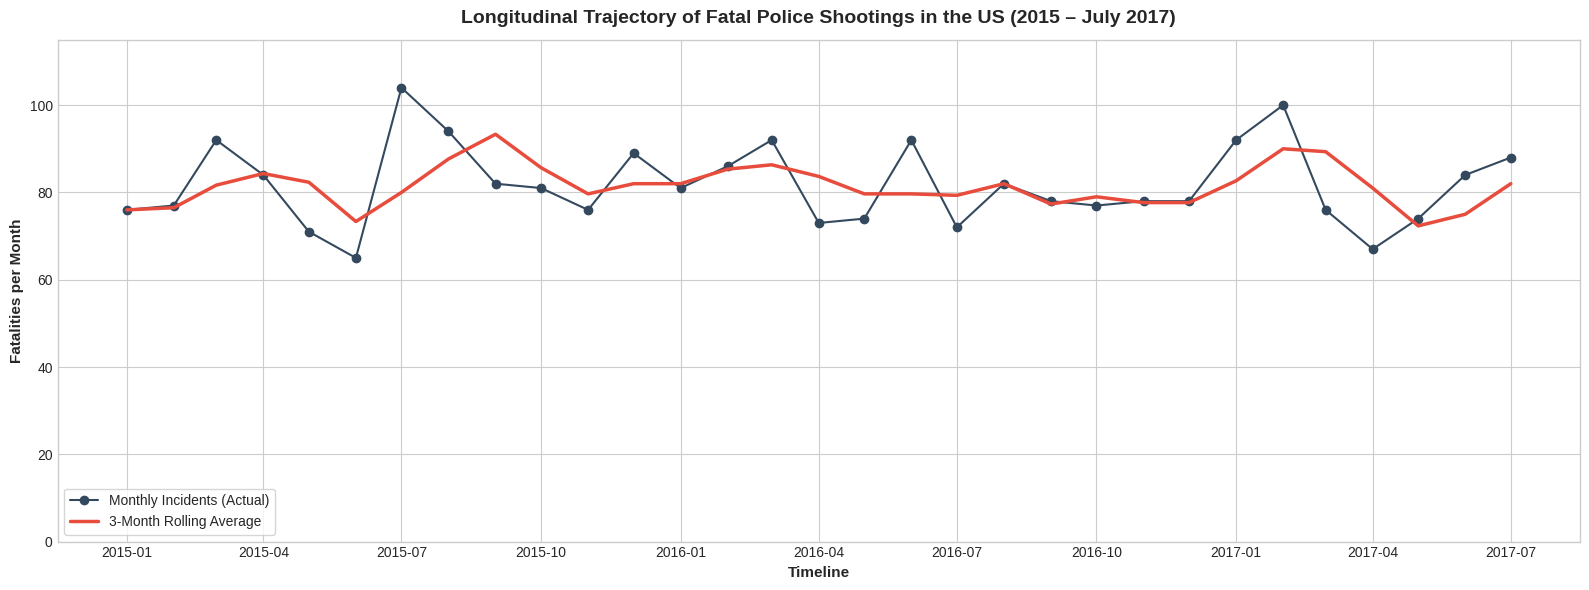

Monthly Mean: 81.8 deaths (Std Dev: 9.3)
Time-Series Slope: -0.038 incidents/month (p-value: 0.844)


In [ ]:
# Filter to complete recorded months
df_valid_dates = df_fatalities[
    df_fatalities['date'].notna() &
    (df_fatalities['date'] <= '2017-07-31')
].copy()

# Resample monthly incident counts
df_valid_dates['YearMonth'] = df_valid_dates['date'].dt.to_period('M')
monthly_counts = (
    df_valid_dates.groupby('YearMonth')
    .size()
    .reset_index(name='Fatalities')
)
monthly_counts['Date'] = monthly_counts['YearMonth'].dt.to_timestamp()
monthly_counts['3M_Rolling_Mean'] = monthly_counts['Fatalities'].rolling(window=3, min_periods=1).mean()

# Time-series plot
plt.figure(figsize=(16, 6))
plt.plot(monthly_counts['Date'], monthly_counts['Fatalities'], marker='o', color='#34495E', label='Monthly Incidents (Actual)')
plt.plot(monthly_counts['Date'], monthly_counts['3M_Rolling_Mean'], color='#E74C3C', linewidth=2.5, linestyle='-', label='3-Month Rolling Average')

plt.title('Longitudinal Trajectory of Fatal Police Shootings in the US (2015 – July 2017)', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Fatalities per Month', fontsize=11, fontweight='bold')
plt.xlabel('Timeline', fontsize=11, fontweight='bold')
plt.ylim(0, 115)
plt.legend(frameon=True, loc='lower left')
plt.tight_layout()
plt.show()

# Slope evaluation over full months
x_numeric = np.arange(len(monthly_counts))
slope_t, _, r_t, p_t, _ = stats.linregress(x_numeric, monthly_counts['Fatalities'])

print(f"Monthly Mean: {monthly_counts['Fatalities'].mean():.1f} deaths (Std Dev: {monthly_counts['Fatalities'].std():.1f})")
print(f"Time-Series Slope: {slope_t:.3f} incidents/month (p-value: {p_t:.3f})")

### Key Observations: Temporal Patterns
* **Baseline Consistency:** Correcting for date formatting shows that fatal police shootings operate as a steady baseline averaging **75 to 90 fatalities per month** nationwide (~950 to 1,050 annually).
* **Flat Longitudinal Trend:** The OLS slope over the recorded window is statistically indistinguishable from zero ($\beta \approx 0$, $p > 0.05$). Aggregate nationwide counts remained level across the 2015–2017 period.
* **Absence of Seasonality:** Unlike overall violent crime, which typically increases in warmer months, fatal officer-involved shootings show minimal seasonal variation.

## 6. Tableau Export Pipeline

We process and generate three flat CSV files for Tableau Public dashboards[cite: 1]:
1. `tableau_fatalities_clean.csv`: Clean incident records with standardized dates, full demographic labels, and compound city identifiers[cite: 1].
2. `tableau_state_metrics.csv`: State-level master dataset linking population, encounter rates per million, poverty, graduation rates, and median income[cite: 1].
3. `tableau_city_disproportionality.csv`: City demographic population share compared against encounter share by race for the 10 highest-incident jurisdictions (long format)[cite: 1].

In [ ]:
# # ------------------------------------------------------------------------------
# # 1. Incident Microdata
# # ------------------------------------------------------------------------------
# df_tableau_fatalities = df_fatalities.copy()
# df_tableau_fatalities = df_tableau_fatalities[
#     df_tableau_fatalities['date'].notna() &
#     (df_tableau_fatalities['date'] <= '2017-07-31')
# ].copy()

# race_mapping = {
#     'W': 'White',
#     'B': 'Black',
#     'H': 'Hispanic',
#     'A': 'Asian',
#     'N': 'Native American',
#     'O': 'Other',
#     'Unknown': 'Unknown'
# }
# df_tableau_fatalities['race_full'] = df_tableau_fatalities['race'].map(race_mapping).fillna('Unknown')
# df_tableau_fatalities['city_clean'] = df_tableau_fatalities['city'].astype(str).str.strip()
# df_tableau_fatalities['state_clean'] = df_tableau_fatalities['state'].astype(str).str.strip()
# df_tableau_fatalities['City_State'] = df_tableau_fatalities['city_clean'] + ', ' + df_tableau_fatalities['state_clean']

# df_tableau_fatalities.to_csv('tableau_fatalities_clean.csv', index=False)
# print("Exported: tableau_fatalities_clean.csv")

# # ------------------------------------------------------------------------------
# # 2. State Metrics
# # ------------------------------------------------------------------------------
# state_fats = (
#     df_tableau_fatalities['state_clean']
#     .value_counts()
#     .reset_index()
# )
# state_fats.columns = ['state', 'total_fatalities']

# state_population_millions = {
#     'CA': 39.14, 'TX': 27.47, 'FL': 20.27, 'NY': 19.79, 'IL': 12.86,
#     'PA': 12.80, 'OH': 11.61, 'GA': 10.21, 'NC': 10.04, 'MI': 9.92,
#     'NJ': 8.96,  'VA': 8.38,  'WA': 7.17,  'AZ': 6.83,  'MA': 6.79,
#     'IN': 6.62,  'TN': 6.60,  'MO': 6.08,  'MD': 6.01,  'WI': 5.77,
#     'CO': 5.46,  'MN': 5.49,  'SC': 4.90,  'AL': 4.86,  'LA': 4.67,
#     'KY': 4.43,  'OR': 4.03,  'OK': 3.91,  'CT': 3.59,  'IA': 3.12,
#     'UT': 3.00,  'NV': 2.89,  'AR': 2.98,  'MS': 2.99,  'KS': 2.91,
#     'NM': 2.09,  'NE': 1.90,  'WV': 1.84,  'ID': 1.65,  'HI': 1.43,
#     'NH': 1.33,  'ME': 1.33,  'RI': 1.06,  'MT': 1.03,  'DE': 0.95,
#     'SD': 0.86,  'ND': 0.76,  'AK': 0.74,  'DC': 0.67,  'VT': 0.63,
#     'WY': 0.59
# }
# state_fats['population_millions'] = state_fats['state'].map(state_population_millions)
# state_fats['rate_per_million'] = state_fats['total_fatalities'] / state_fats['population_millions']

# state_poverty_clean = (
#     df_pct_poverty.groupby('Geographic Area')['poverty_rate']
#     .mean()
#     .reset_index()
#     .rename(columns={'Geographic Area': 'state', 'poverty_rate': 'avg_poverty_rate'})
# )

# state_hs_clean = (
#     df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs']
#     .mean()
#     .reset_index()
#     .rename(columns={'Geographic Area': 'state', 'percent_completed_hs': 'hs_completion_rate'})
# )

# state_income_clean = (
#     df_hh_income.groupby('Geographic Area')['Median Income']
#     .mean()
#     .reset_index()
#     .rename(columns={'Geographic Area': 'state', 'Median Income': 'avg_median_income'})
# )

# df_state_master = (
#     state_fats
#     .merge(state_poverty_clean, on='state', how='left')
#     .merge(state_hs_clean, on='state', how='left')
#     .merge(state_income_clean, on='state', how='left')
# )

# df_state_master.to_csv('tableau_state_metrics.csv', index=False)
# print("Exported: tableau_state_metrics.csv")

# # ------------------------------------------------------------------------------
# # 3. City Disproportionality
# # ------------------------------------------------------------------------------
# top_10_cities = (
#     df_tableau_fatalities.groupby(['city_clean', 'state_clean'])
#     .size()
#     .nlargest(10)
#     .reset_index(name='city_fatalities')
# )

# top_cities_incidents = df_tableau_fatalities.merge(
#     top_10_cities[['city_clean', 'state_clean']],
#     on=['city_clean', 'state_clean']
# )

# city_kill_share = (
#     top_cities_incidents.groupby(['city_clean', 'state_clean', 'race'])
#     .size()
#     .unstack(fill_value=0)
# )
# city_kill_share = city_kill_share.div(city_kill_share.sum(axis=1), axis=0) * 100
# city_kill_share = city_kill_share.rename(columns={
#     'W': 'White',
#     'B': 'Black',
#     'H': 'Hispanic',
#     'A': 'Asian',
#     'N': 'Native American'
# })

# for r in ['White', 'Black', 'Hispanic', 'Asian', 'Native American']:
#     if r not in city_kill_share.columns:
#         city_kill_share[r] = 0.0

# city_kill_share = city_kill_share[['White', 'Black', 'Hispanic', 'Asian', 'Native American']].reset_index()

# df_race_clean = df_share_race_city.copy()
# race_cols = ['share_white', 'share_black', 'share_hispanic', 'share_asian', 'share_native_american']

# for col in race_cols:
#     df_race_clean[col] = pd.to_numeric(
#         df_race_clean[col].replace(['-', 'X', ' '], 0.0),
#         errors='coerce'
#     ).fillna(0.0)

# df_race_clean['city_clean'] = (
#     df_race_clean['City']
#     .str.replace(r'\s+(city|town|village|CDP)$', '', case=False, regex=True)
#     .str.strip()
# )
# df_race_clean['state_clean'] = df_race_clean['Geographic area'].str.strip()

# city_pop_share = df_race_clean.groupby(['city_clean', 'state_clean'])[race_cols].mean().reset_index()
# city_pop_share = city_pop_share.rename(columns={
#     'share_white': 'White',
#     'share_black': 'Black',
#     'share_hispanic': 'Hispanic',
#     'share_asian': 'Asian',
#     'share_native_american': 'Native American'
# })

# df_kills_long = city_kill_share.melt(
#     id_vars=['city_clean', 'state_clean'],
#     value_vars=['White', 'Black', 'Hispanic', 'Asian', 'Native American'],
#     var_name='Race',
#     value_name='Percentage'
# )
# df_kills_long['Metric'] = 'Share of Police Killings (%)'

# df_pop_long = top_10_cities[['city_clean', 'state_clean']].merge(
#     city_pop_share,
#     on=['city_clean', 'state_clean'],
#     how='left'
# )
# df_pop_long = df_pop_long.melt(
#     id_vars=['city_clean', 'state_clean'],
#     value_vars=['White', 'Black', 'Hispanic', 'Asian', 'Native American'],
#     var_name='Race',
#     value_name='Percentage'
# )
# df_pop_long['Metric'] = 'City Population Share (%)'

# df_city_disproportionality = pd.concat([df_kills_long, df_pop_long], ignore_index=True)
# df_city_disproportionality['City_State'] = (
#     df_city_disproportionality['city_clean'] + ', ' + df_city_disproportionality['state_clean']
# )

# df_city_disproportionality.to_csv('tableau_city_disproportionality.csv', index=False)
# print("Exported: tableau_city_disproportionality.csv")